## Data vizualization
In this notebook, I will try toimplement meaningful visualization to better understand the structure of the data.
Inspired from subjects_loop.ipynb

In [1]:
# Imports
import os
import numpy as np
import mne
from mne_bids import (
    find_matching_paths,
    read_raw_bids,
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mne.stats import permutation_cluster_test

from mne import Epochs
from mne.time_frequency import EpochsTFRArray

from mne.datasets import fetch_fsaverage

import matplotlib 
matplotlib.use('nbAgg')
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


In [2]:
# This function plots the results of an F-test performed on two conditions. 

# It creates three subplots: 
#   - the first shows the average signal for each condition, 
#   - the second shows the difference between the two conditions, 
#   - and the third shows the results of a permutation cluster test to identify significant differences between the conditions over time.

def plot_f_test(epochs, picks, conditions, condition_labels=['Condition 1', 'Condition 2']):
    epochs_ = epochs.copy().load_data()
    times = epochs_.times

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    fig.suptitle("Channel : " + picks[0])

    line_color = 'grey'
    unit = 'mV'
    # Plot signals
    ds = []
    conditions_data = []
    for condition, condition_name  in zip(conditions, condition_labels):
        condition_data = epochs_[condition].get_data(picks=picks, units=unit)[:,0,:]
        conditions_data.append(condition_data)

        for epoch_data in condition_data:
            for t, data in zip(times, epoch_data):
                ds.append({'condition': condition_name, 'time': t, 'data': data})
        df = pd.DataFrame(ds)

    ax = axes[0]
    sns.lineplot(x='time', y='data', data=df, ax=ax, hue='condition', hue_order=condition_labels, palette='tab10')
    x_lims = ax.get_xlim()
    y_lims = ax.get_ylim()
    ax.vlines(0, y_lims[0]*2,  y_lims[1]*2, color=line_color)
    ax.hlines(0, x_lims[0]*2,  x_lims[1]*2, color=line_color)
    ax.set_ylim(y_lims)
    ax.set_xlim(x_lims)
    ax.set_ylabel(f"Amplitude ({unit})")

    # Get original legend handles and labels
    handles, labels = ax.get_legend_handles_labels()
    hue_counts = {}
    for label, condition in zip(labels, conditions):
        hue_counts[label] = len(epochs_[condition])
    # Modify labels to include sample counts
    new_labels = [f"{label} (n={hue_counts[label]})" for label in labels]
    ax.legend(handles, new_labels, title="Condition")


    # Plot contrast
    ax = axes[1]
    diff = conditions_data[0].mean(axis=0) - conditions_data[1].mean(axis=0)
    sns.lineplot(x=times, y=diff, ax=ax, color='teal')
    x_lims = ax.get_xlim()
    y_lims = ax.get_ylim()
    ax.vlines(0, y_lims[0]*2,  y_lims[1]*2, color=line_color)
    ax.hlines(0, x_lims[0]*2,  x_lims[1]*2, color=line_color)
    ax.set_ylim(y_lims)
    ax.set_xlim(x_lims)
    ax.set_ylabel(f"Amplitude difference ({unit})")


    # Plot permutation test
    ax = axes[2]
    threshold = None
    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        conditions_data,
        n_permutations=1000,
        threshold=threshold,
        tail=1,
        n_jobs=None,
        out_type="mask",
    )

    h = None
    for i_c, c in enumerate(clusters):
        c = c[0]
        start = c.start
        stop = c.stop - 1
        if cluster_p_values[i_c] <= 0.05:
            h = ax.axvspan(times[start], times[stop], color="r", alpha=0.3)
        else:
            ax.axvspan(times[start], times[stop], color=(0.3, 0.3, 0.3), alpha=0.3)

    sns.lineplot(x=times, y=T_obs, ax=ax, color='green')
    if h is not None:
        ax.legend((h,), ("cluster p-value < 0.05",))
    ax.set_xlabel("time (s)")
    ax.set_ylabel("f-values")

    y_lims = ax.get_ylim()
    ax.vlines(0, y_lims[0]*2,  y_lims[1]*2, color=line_color)
    ax.set_ylim(y_lims)
    return fig

In [3]:
# Access the data
bids_root = "/media/RCPNAS/sEEG_MARS_Alison/"
subjects = ["01"] #["01", "02", "03", "04", "06"]  # For now, just testing with 1 subject

# This loop loads the raw data for each subject, adds bad annotations, and loads the events. 
# It then filters the events to include only correct trials with a duration of less than 5 seconds, 
# and prints the count of events for each condition.

for subject in subjects:
    bids_path = find_matching_paths(
    subjects=subject, sessions="retrieval", tasks="mars", datatypes="ieeg", extensions="vhdr", root=bids_root
    )[0]
    raw = read_raw_bids(bids_path=bids_path, verbose=False)

    # bad annotations
    bad_annotation_path = str(bids_path.copy().fpath).replace("_ieeg.vhdr", "_annot.csv")
    bad_annotations = mne.read_annotations(bad_annotation_path)
    # -- TODO: Check if the original time is needed for the analysis, and if so, set it to the appropriate value instead of None.
    new_bad_annotations = mne.Annotations(
        onset=bad_annotations.onset,
        duration=bad_annotations.duration,
        description=bad_annotations.description,
        orig_time=None  # Set directly in constructor
    )
    # --
    raw.set_annotations(raw.annotations + new_bad_annotations)

    # load events
    events_path = bids_path.copy().update(extension="tsv", suffix="events")
    df_events = pd.read_csv(events_path, sep="\t")
    df_events =  df_events[(df_events['correct'] == True) & (df_events['duration'] < 5)]
    print(subject)
    print(df_events[['condition', 'onset']].groupby('condition').count())


/tmp/ipykernel_2336714/305893368.py:13: RuntimeWarning: Did not find any electrodes.tsv associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipykernel_2336714/305893368.py:13: RuntimeWarning: Did not find any coordsystem.json associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


01
               onset
condition           
Always            16
Current           18
Distant Futur      2
Distant Past       7
Futur              7
Never             19
Past               5


In [4]:
for i, (onset, duration, desc) in enumerate(zip(
    raw.annotations.onset, 
    raw.annotations.duration, 
    raw.annotations.description
)):
    print(f"Annotation {i+1}: onset={onset:.2f}s, duration={duration:.2f}s, description={desc}")

Annotation 1: onset=0.00s, duration=1.27s, description=BAD
Annotation 2: onset=52.78s, duration=4.37s, description=2
Annotation 3: onset=59.38s, duration=4.66s, description=5
Annotation 4: onset=65.81s, duration=3.82s, description=2
Annotation 5: onset=71.71s, duration=5.03s, description=5
Annotation 6: onset=78.63s, duration=10.82s, description=3
Annotation 7: onset=91.73s, duration=4.03s, description=3
Annotation 8: onset=97.63s, duration=3.45s, description=6
Annotation 9: onset=103.20s, duration=2.65s, description=2
Annotation 10: onset=107.61s, duration=2.37s, description=6
Annotation 11: onset=111.81s, duration=5.54s, description=5
Annotation 12: onset=117.32s, duration=0.52s, description=BAD
Annotation 13: onset=119.56s, duration=12.70s, description=3
Annotation 14: onset=134.50s, duration=2.43s, description=6
Annotation 15: onset=138.88s, duration=5.90s, description=3
Annotation 16: onset=146.53s, duration=4.43s, description=2
Annotation 17: onset=152.86s, duration=1.94s, descri

Using matplotlib as 2D backend.


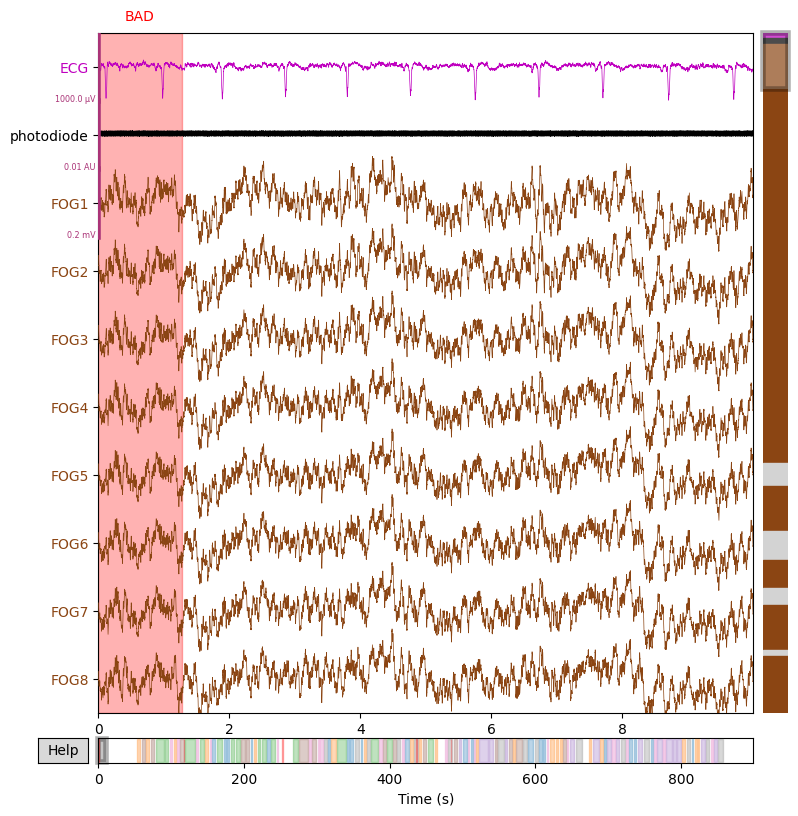

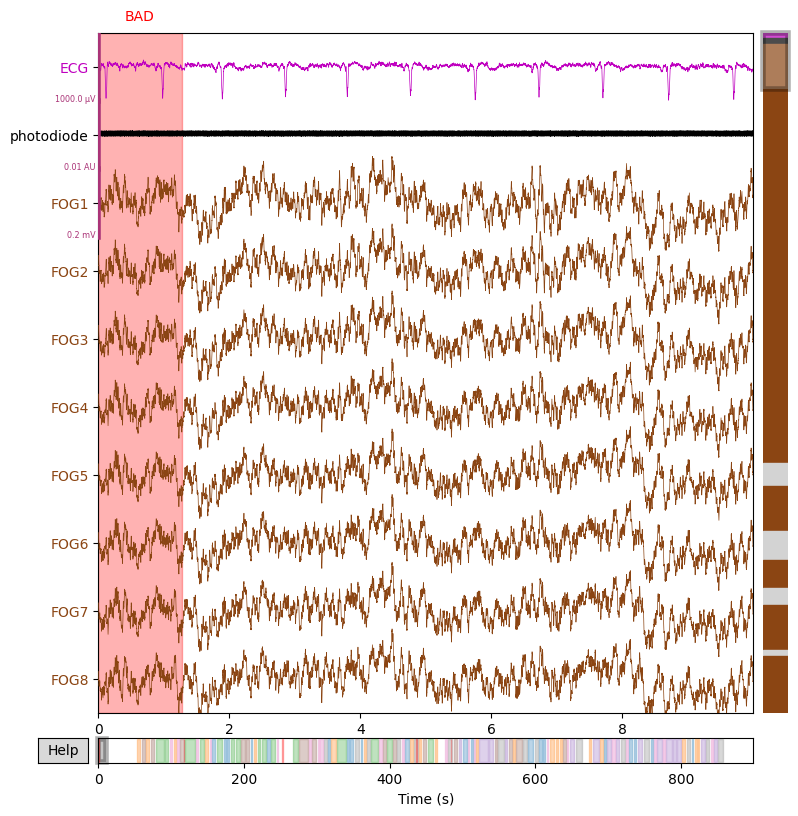

In [5]:
# Plot raw data with annotations visible
raw.plot(n_channels=10, duration=10, show=True)
# Annotations will appear as colored blocks at the top

In [6]:
n_jobs = 12

# This loop processes the raw data for each subject, 
# including filtering, epoching, and plotting the results of the F-test for specific conditions.

for subject in subjects:
    bids_path = find_matching_paths(
    subjects=subject, sessions="retrieval", tasks="mars", datatypes="ieeg", extensions="vhdr", root=bids_root
    )[0]
    raw = read_raw_bids(bids_path=bids_path, verbose=False)

    # bad annotations
    bad_annotation_path = str(bids_path.copy().fpath).replace("_ieeg.vhdr", "_annot.csv")
    bad_annotations = mne.read_annotations(bad_annotation_path)
    # -- TODO: Check if the original time is needed for the analysis, and if so, set it to the appropriate value instead of None.
    new_bad_annotations = mne.Annotations(
        onset=bad_annotations.onset,
        duration=bad_annotations.duration,
        description=bad_annotations.description,
        orig_time=None  # Set directly in constructor
    )
    # --
    raw.set_annotations(raw.annotations + new_bad_annotations)


    # load events
    events_path = bids_path.copy().update(extension="tsv", suffix="events")
    df_events = pd.read_csv(events_path, sep="\t")
    df_events =  df_events[(df_events['correct'] == True) & (df_events['duration'] < 5)]
    events = df_events[['sample', 'duration', 'value']].values.astype(int)

    event_id = dict()
    for condition in df_events['condition'].unique():
        event_id[condition] =  df_events[df_events['condition'] == condition]['value'].values[0]


    if "HAD1" in raw.ch_names:
        picks = ['HAD1', 'HAD2', 'HPD1', 'HPD2']
    elif "HAG1" in raw.ch_names:
        picks = ['HAG1', 'HAG2', 'HPG1', 'HPG2']

    raw.load_data()
    # filter
    raw.filter(.5, 30, picks='seeg', fir_design='firwin', n_jobs=n_jobs, verbose=False)
    # remove power line 50 Hz and harmonics
    raw.notch_filter(np.arange(50, 251, 50),
                    picks='seeg', 
                    notch_widths=4,
                    n_jobs=n_jobs,
                    verbose=False)

    raw_seeg = raw.copy()
    good_channels = list(set(raw_seeg.ch_names) - set(raw_seeg.info['bads']) - set(['photodiode']))
    #raw_seeg.info['bads'] = []
    raw_seeg.set_eeg_reference(good_channels, ch_type='seeg')

    epochs = mne.Epochs(raw_seeg, events, event_id=event_id, tmin=-0.5, tmax=2, baseline=(-0.5, 0),  detrend=1, event_repeated='raise', reject_by_annotation=True).load_data()
    epochs.resample(250) # data resampled at 250Hz --> reduces computations
    for pick in picks:
        if pick in epochs.ch_names:
            for condition_label, condition,  in [('Futur', ["Futur", "Distant Futur"]), ('Past', ["Past", "Distant Past"])]:
                condition = [c for c in condition if c in epochs.event_id]
                if len(epochs[condition]):
                    print(f"Plotting {subject} {pick} {condition_label}")
                    conditions = [['Current'], condition]
                    fig = plot_f_test(epochs, [pick], conditions, condition_labels=['Current', condition_label])
                    fig.savefig(f"figures/{subject}_{pick}_{condition_label}.png", dpi=300)
                    plt.close(fig)
            else:
                print(f"Skipping {subject} {pick} {condition_label}, no epochs found for conditions {condition}")

Reading 0 ... 1843200  =      0.000 ...   900.000 secs...


/tmp/ipykernel_2336714/4101563254.py:10: RuntimeWarning: Did not find any electrodes.tsv associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipykernel_2336714/4101563254.py:10: RuntimeWarning: Did not find any coordsystem.json associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


Applying a custom ('sEEG',) reference.
Not setting metadata
74 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 74 events and 5121 original time points ...
0 bad epochs dropped
Plotting 01 HAG1 Futur
Using a threshold of 4.241699
stat_fun(H1): min=2.770070286211447e-05 max=8.540498290490918
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Plotting 01 HAG1 Past
Using a threshold of 4.195972
stat_fun(H1): min=4.936826247950917e-08 max=8.228760513374496
Running initial clustering …
Found 3 clusters


...

Skipping 01 HPG1 Past, no epochs found for conditions ['Past', 'Distant Past']
Plotting 01 HPG2 Futur
Using a threshold of 4.241699
stat_fun(H1): min=1.4996530660270805e-06 max=6.632400775729049
Running initial clustering …
Found 7 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Plotting 01 HPG2 Past
Using a threshold of 4.195972
stat_fun(H1): min=1.598801600593416e-08 max=9.475305401200579
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Skipping 01 HPG2 Past, no epochs found for conditions ['Past', 'Distant Past']


In [7]:
tmin = -1
tmax = 5
baseline = (-1, 0)

fr_bands = [[3,7],[15,40],[60,100]]
fr_bands_name = ['Theta','Beta','HpR']


n_jobs = 12

# This loop processes the raw data for each subject, 
# including filtering, epoching, and plotting the power spectral density (PSD) for specific conditions and channels of interest.

for subject in subjects:
    bids_path = find_matching_paths(
    subjects=subject, sessions="retrieval", tasks="mars", datatypes="ieeg", extensions="vhdr", root=bids_root
    )[0]
    raw = read_raw_bids(bids_path=bids_path, verbose=False)

    # bad annotations
    bad_annotation_path = str(bids_path.copy().fpath).replace("_ieeg.vhdr", "_annot.csv")
    bad_annotations = mne.read_annotations(bad_annotation_path)
    # -- TODO: Check if the original time is needed for the analysis, and if so, set it to the appropriate value instead of None.
    new_bad_annotations = mne.Annotations(
        onset=bad_annotations.onset,
        duration=bad_annotations.duration,
        description=bad_annotations.description,
        orig_time=None  # Set directly in constructor
    )
    # --
    raw.set_annotations(raw.annotations + new_bad_annotations)


    # load events
    events_path = bids_path.copy().update(extension="tsv", suffix="events")
    df_events = pd.read_csv(events_path, sep="\t")
    df_events =  df_events[(df_events['correct'] == True) & (df_events['duration'] < 5)]
    events = df_events[['sample', 'duration', 'value']].values.astype(int)

    event_id = dict()
    for condition in df_events['condition'].unique():
        event_id[condition] =  df_events[df_events['condition'] == condition]['value'].values[0]


    if "HAD1" in raw.ch_names:
        picks = ['HAD1', 'HAD2', 'HPD1', 'HPD2']
    elif "HAG1" in raw.ch_names:
        picks = ['HAG1', 'HAG2', 'HPG1', 'HPG2']

    raw.load_data()
    # filter
    raw.filter(.5, 40, picks='seeg', fir_design='firwin', n_jobs=n_jobs, verbose=False)
    # remove power line 50 Hz and harmonics
    raw.notch_filter(np.arange(50, 251, 50),
                    picks='seeg', 
                    notch_widths=4,
                    n_jobs=n_jobs,
                    verbose=False)

    raw_seeg = raw.copy()
    good_channels = list(set(raw_seeg.ch_names) - set(raw_seeg.info['bads']) - set(['photodiode']))
    #raw_seeg.info['bads'] = []
    raw_seeg.set_eeg_reference(good_channels, ch_type='seeg')

    epochs = mne.Epochs(raw_seeg, events, event_id=event_id, tmin=tmin, tmax=tmax, baseline=baseline, detrend=None, event_repeated='drop', reject_by_annotation=True).drop_bad()

    psd = epochs.compute_psd(fmin=0, fmax=50, tmin=0, tmax=tmax)
    df_psd = psd.to_data_frame()
    for ch_name in epochs.ch_names:
        try:
            df_psd[ch_name] = 10 * np.log10(df_psd[ch_name])
        except:
            pass

    group_conditions = []
    for condition in df_psd['condition'].values:
        if condition in ['Distant Past', 'Past']:
            group_conditions.append('Past')
        elif condition in ['Distant Futur', 'Futur']:
            group_conditions.append('Futur')
        else:
            group_conditions.append(condition)

    df_psd['group_condition'] = group_conditions


    try:
        fig, axes = plt.subplots(1, len(picks), figsize=(50, 5))

        for c,ch_name in enumerate(picks):
            ax = axes[c]
            sns.lineplot(ax=ax,
                        x="freq", y=ch_name,
                        hue="group_condition",
                        hue_order=['Past', 'Current', 'Futur'],
                        errorbar=('ci', 95),
                        data=df_psd)
            ax.set_xlim([1, 50])
            ax.set_title(ch_name)

            fig.savefig(f"figures/psd/{subject}.png", dpi=300)
            plt.close(fig)
    except Exception as e:
        print(f"Error processing {subject}: {e}")

/tmp/ipykernel_2336714/1337469784.py:18: RuntimeWarning: Did not find any electrodes.tsv associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipykernel_2336714/1337469784.py:18: RuntimeWarning: Did not find any coordsystem.json associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


Reading 0 ... 1843200  =      0.000 ...   900.000 secs...
Applying a custom ('sEEG',) reference.
Not setting metadata
74 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 74 events and 12289 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 74 events and 12289 original time points ...
    Using multitaper spectrum estimation with 7 DPSS windows


/tmp/ipykernel_2336714/1337469784.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_psd['group_condition'] = group_conditions


In [8]:
def get_reordered_indices(lst, order):
    # Create a dictionary to map each element in the order to its priority index
    order_dict = {value: index for index, value in enumerate(order)}
    
    # Sort the indices of the list based on the corresponding element's priority in order_dict
    return sorted(range(len(lst)), key=lambda i: order_dict.get(lst[i], float('inf')))

In [9]:
sequence = []
condition_order = ['Never', 'Always', 'Distant Past', 'Past', 'Current', 'Futur', 'Distant Futur']
for condition in condition_order:
    if condition in epochs.event_id.keys():
        sequence.append(condition)

In [10]:
sequence

['Never',
 'Always',
 'Distant Past',
 'Past',
 'Current',
 'Futur',
 'Distant Futur']

In [11]:
tmin = -2
tmax = 5

freqs = np.arange(90, 150.0, 5) 
bandwidth =  5

# This loop processes the raw data for each subject, 
# including filtering, epoching
# Then we filter the data in specific frequency bands, compute the Hilbert transform to get the power, and plot the results for specific conditions and channels of interest.

for subject in subjects:
    bids_path = find_matching_paths(
        subjects=subject, sessions="retrieval", tasks="mars", datatypes="ieeg", extensions="vhdr", root=bids_root
    )[0]
    raw = read_raw_bids(bids_path=bids_path, verbose=False)

    # load events
    events_path = bids_path.copy().update(extension="tsv", suffix="events")
    df_events = pd.read_csv(events_path, sep="\t")
    df_events = df_events[(df_events['correct'] == True) & (df_events['duration'] < 5)]
    events = df_events[["sample", "duration", "value"]].to_numpy()
    events[:, 1] = 0
    events = events.astype(int)
    event_id = dict(zip(df_events['condition'], df_events['value']))

    print("Unique event codes in data:", set(events[:, 2]))

    # annotations
    annotations_path = str(bids_path.fpath)[:-9] + "annot.csv"
    annotations = mne.read_annotations(annotations_path)
    # -- TODO: Check if the original time is needed for the analysis, and if so, set it to the appropriate value instead of None.
    new_annotations = mne.Annotations(
        onset=bad_annotations.onset,
        duration=bad_annotations.duration,
        description=bad_annotations.description,
        orig_time=None  # Set directly in constructor
    )
    # --
    raw.set_annotations(new_annotations)

    picks = None
    if "HAD1" in raw.ch_names:
        picks = ['HAD1', 'HAD2', 'HPD1', 'HPD2']
    elif "HAG1" in raw.ch_names:
        picks = ['HAG1', 'HAG2', 'HPG1', 'HPG2']
    else:
        raise ValueError("No channel found in the data.")
    picks = list(set(picks).intersection(set(raw.ch_names))) 
    raw.load_data()

    # filter
    raw.filter(.1, 250, picks='seeg', fir_design='firwin', n_jobs=n_jobs, verbose=False)
    # remove power line 50 Hz and harmonics
    raw.notch_filter(np.arange(50, 251, 50),
                    picks='seeg', 
                    notch_widths=4,
                    n_jobs=n_jobs,
                    verbose=False)


    good_channels = list(set(raw.ch_names) - set(raw.info['bads']) - set(['photodiode']))
    raw.set_eeg_reference(good_channels, ch_type='seeg')

    epochs = mne.Epochs(raw, events, event_id=event_id, tmin=tmin, tmax=tmax, baseline=(-0.5, 0),  detrend=1, event_repeated='raise', reject_by_annotation=True).load_data()

    data = np.zeros(
        (len(epochs), len(picks), freqs.size, int((tmax - tmin) * raw.info['sfreq']) + 1), dtype=complex
    )
    data_norm = np.zeros(
        (len(epochs), len(picks), freqs.size, int((tmax - tmin) * raw.info['sfreq']) + 1), dtype=complex
    )
    for idx, freq in enumerate(freqs):
        # Filter raw data and re-epoch to avoid the filter being longer than
        # the epoch data for low frequencies and short epochs, such as here.
        raw_filter = raw.copy()
        raw_filter.pick(picks)
        raw_filter.filter(
            l_freq=freq - bandwidth / 2,
            h_freq=freq + bandwidth / 2,
        )
        raw_filter.apply_hilbert() # power 
        epochs_hilb = Epochs(
            raw_filter, events, event_id=event_id, tmin=tmin, tmax=tmax, baseline=None, event_repeated='raise', reject_by_annotation=True).load_data()
        data[:, :, idx] = epochs_hilb.get_data(picks)

    power_data = np.abs(data)# ** 2 # Puissance instantanée
    power_norm_data = power_data / np.mean(power_data, axis=-1, keepdims=True) # Norm

    power = EpochsTFRArray(epochs_hilb.info, power_data, epochs.times, freqs, events=epochs_hilb.events, event_id=event_id, method="hilbert")
    power_norm = EpochsTFRArray(epochs_hilb.info, power_norm_data, epochs.times, freqs, events=epochs_hilb.events, event_id=event_id, method="hilbert")


    sequence = []
    condition_order = ['Never', 'Always', 'Distant Past', 'Past', 'Current', 'Futur', 'Distant Futur']
    for condition in condition_order:
        if condition in epochs.event_id.keys():
            sequence.append(epochs.event_id[condition])
            print(f"  {condition}: code {epochs.event_id[condition]}")

    print(f"\nFinal sequence: {sequence}")
    print(f"Unique codes in sequence: {set(sequence)}")

    if len(sequence) != len(set(sequence)):
        print("❌ DUPLICATES FOUND in sequence!")

    order = get_reordered_indices(epochs_hilb.events[:,2], sequence)
    print(f"Reordered indices: {order}")
    h_lines_y = np.where(np.diff(epochs_hilb.events[order][:,2]) != 0)[0]

    data_ = np.mean(power_norm.get_data(picks), axis=2)
    epoch_high_freq = mne.EpochsArray(data_, epochs_hilb.info, tmin=epochs_hilb.times[0], events=epochs_hilb.events, event_id=event_id, baseline=None)
    epoch_high_freq.apply_baseline((-0.5, -0.1))

    """ for pick in picks:
        fig = epoch_high_freq.plot_image(picks=pick, order=order, show=False)[0]
        ax = fig.get_axes()[0]
        for y in h_lines_y:
            ax.hlines(y, *ax.get_xlim(), color='black', linestyle='--', linewidth=1)
        fig.savefig(f"figures/{subject}_{pick}_high_freq.png", dpi=300) """
    for pick in picks:
        fig = epoch_high_freq.plot_image(picks=pick, order=order, show=False)[0]
        ax = fig.get_axes()[0]
        
        # Add separator lines
        for y in h_lines_y:
            ax.hlines(y, *ax.get_xlim(), color='black', linestyle='--', linewidth=1)
        
        # Add condition labels
        condition_sequence = epochs_hilb.events[order][:,2]
        current_condition = condition_sequence[0]
        start_idx = 0
        
        for i, y in enumerate(list(h_lines_y) + [len(condition_sequence)]):
            # Find which condition this segment belongs to
            segment_condition = condition_sequence[start_idx]
            print(f"Segment {i+1}: condition code {segment_condition}, start index {start_idx}, end index {y}")
            # Get condition name from event_id
            condition_name = [k for k, v in event_id.items() if v == segment_condition][0]
            # Add text label
            mid_point = (start_idx + y) / 2
            ax.text(ax.get_xlim()[1] * 1.02, mid_point, condition_name, 
                    va='center', fontsize=8)
            start_idx = y
        
        fig.savefig(f"figures/{subject}_{pick}_high_freq.png", dpi=300, bbox_inches='tight')


Unique event codes in data: {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)}
Reading 0 ... 1843200  =      0.000 ...   900.000 secs...


/tmp/ipykernel_2336714/1860224210.py:15: RuntimeWarning: Did not find any electrodes.tsv associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipykernel_2336714/1860224210.py:15: RuntimeWarning: Did not find any coordsystem.json associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


Applying a custom ('sEEG',) reference.
Not setting metadata
74 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 74 events and 14337 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 88 - 92 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 87.50
- Lower transition bandwidth: 21.88 Hz (-6 dB cutoff frequency: 76.56 Hz)
- Upper passband edge: 92.50 Hz
- Upper transition bandwidth: 23.12 Hz (-6 dB cutoff frequency: 104.06 Hz)
- Filter length: 309 samples (0.151 s)

Not setting metadata
74 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 74 events and 14337 original time poin

/tmp/ipykernel_2336714/1860224210.py:121: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  fig = epoch_high_freq.plot_image(picks=pick, order=order, show=False)[0]


Segment 1: condition code 6, start index 0, end index 18
Segment 2: condition code 6, start index 18, end index 34
Segment 3: condition code 1, start index 34, end index 41
Segment 4: condition code 4, start index 41, end index 46
Segment 5: condition code 7, start index 46, end index 64
Segment 6: condition code 2, start index 64, end index 71
Segment 7: condition code 5, start index 71, end index 74
Not setting metadata
74 matching events found
No baseline correction applied
0 projection items activated


...

Segment 1: condition code 6, start index 0, end index 18
Segment 2: condition code 6, start index 18, end index 34
Segment 3: condition code 1, start index 34, end index 41
Segment 4: condition code 4, start index 41, end index 46
Segment 5: condition code 7, start index 46, end index 64
Segment 6: condition code 2, start index 64, end index 71
Segment 7: condition code 5, start index 71, end index 74
Not setting metadata
74 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2336714/1860224210.py:121: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  fig = epoch_high_freq.plot_image(picks=pick, order=order, show=False)[0]


Segment 1: condition code 6, start index 0, end index 18
Segment 2: condition code 6, start index 18, end index 34
Segment 3: condition code 1, start index 34, end index 41
Segment 4: condition code 4, start index 41, end index 46
Segment 5: condition code 7, start index 46, end index 64
Segment 6: condition code 2, start index 64, end index 71
Segment 7: condition code 5, start index 71, end index 74
Not setting metadata
74 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2336714/1860224210.py:121: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  fig = epoch_high_freq.plot_image(picks=pick, order=order, show=False)[0]


Segment 1: condition code 6, start index 0, end index 18
Segment 2: condition code 6, start index 18, end index 34
Segment 3: condition code 1, start index 34, end index 41
Segment 4: condition code 4, start index 41, end index 46
Segment 5: condition code 7, start index 46, end index 64
Segment 6: condition code 2, start index 64, end index 71
Segment 7: condition code 5, start index 71, end index 74


In [12]:
misc_path = mne.datasets.misc.data_path()
sample_path = mne.datasets.sample.data_path()
subjects_dir = sample_path / "subjects"

In [13]:

# use mne-python's fsaverage data
fetch_fsaverage(subjects_dir=subjects_dir, verbose=True)  # downloads if needed

# Load sample SEEG data with electrode location and make epochs
raw = mne.io.read_raw(misc_path / "seeg" / "sample_seeg_ieeg.fif")

epochs = mne.Epochs(raw, detrend=1, baseline=None)
epochs = epochs["Response"][0]  # just process one epoch of data for speed

0 files missing from root.txt in /home/aboschun/mne_data/MNE-sample-data/subjects
0 files missing from bem.txt in /home/aboschun/mne_data/MNE-sample-data/subjects/fsaverage
Opening raw data file /home/aboschun/mne_data/MNE-misc-data/seeg/sample_seeg_ieeg.fif...
    Range : 1310640 ... 1370605 =   1311.411 ...  1371.411 secs
Ready.
Used Annotations descriptions: [np.str_('Fixation'), np.str_('Go Cue'), np.str_('ISI Onset'), np.str_('Response')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
32 matching events found
No baseline correction applied
0 projection items activated


In [14]:
montage = epochs.get_montage()

# first we need a head to mri transform since the data is stored in "head"
# coordinates, let's load the mri to head transform and invert it
this_subject_dir = misc_path / "seeg"
head_mri_t = mne.coreg.estimate_head_mri_t("sample_seeg", this_subject_dir)
# apply the transform to our montage
montage.apply_trans(head_mri_t)

# now let's load our Talairach transform and apply it
mri_mni_t = mne.read_talxfm("sample_seeg", misc_path / "seeg")
montage.apply_trans(mri_mni_t)  # mri to mni_tal (MNI Taliarach)

# for fsaverage, "mri" and "mni_tal" are equivalent and, since
# we want to plot in fsaverage "mri" space, we need use an identity
# transform to equate these coordinate frames
montage.apply_trans(mne.transforms.Transform(fro="mni_tal", to="mri", trans=np.eye(4)))

epochs.set_montage(montage)

<Epochs | 1 events (good & bad), -0.2 – 0.5 s (baseline off), ~142 KiB, data not loaded,
 np.str_('Response'): 1>

In [1]:
# compute the transform to head for plotting
trans = mne.channels.compute_native_head_t(montage)
# note that this is the same as:
# ``mne.transforms.invert_transform(
#      mne.transforms.combine_transforms(head_mri_t, mri_mni_t))``

view_kwargs = dict(azimuth=105, elevation=100, focalpoint=(0, 0, -15))
brain = mne.viz.Brain(
    "fsaverage",
    subjects_dir=subjects_dir,
    cortex="low_contrast",
    alpha=0.25,
    background="white",
)
brain.add_sensors(epochs.info, trans=trans)
brain.add_head(alpha=0.25, color="tan")
brain.show_view(distance=400, **view_kwargs)

brain.save_image("electrode_locations.png")
print("Saved to electrode_locations.png")

NameError: name 'mne' is not defined

In [25]:
brain = mne.viz.Brain(
    "fsaverage", subjects_dir=subjects_dir, surf="inflated", background="black"
)
brain.add_annotation("aparc.a2009s")
brain.add_sensors(epochs.info, trans=trans)
brain.show_view(distance=500, **view_kwargs)

brain.save_image("figures/fsaverage_inflated.png")

Nearest-neighbor searches will be significantly faster if scikit-learn is installed.
Nearest-neighbor searches will be significantly faster if scikit-learn is installed.
Channel types::	seeg: 119


In [26]:
brain = mne.viz.Brain(
    "fsaverage", subjects_dir=subjects_dir, surf="flat", background="black"
)
brain.add_annotation("aparc.a2009s")
brain.add_sensors(epochs.info, trans=trans)

brain.save_image("figures/fsaverage_flat.png")

Nearest-neighbor searches will be significantly faster if scikit-learn is installed.
Nearest-neighbor searches will be significantly faster if scikit-learn is installed.
Channel types::	seeg: 119


In [27]:
aseg = "aparc+aseg"  # parcellation/anatomical segmentation atlas
labels, colors = mne.get_montage_volume_labels(
    montage, "fsaverage", subjects_dir=subjects_dir, aseg=aseg
)

# separate by electrodes which have names like LAMY 1
electrodes = set(
    [
        "".join([lttr for lttr in ch_name if not lttr.isdigit() and lttr != " "])
        for ch_name in montage.ch_names
    ]
)
print(f"Electrodes in the dataset: {electrodes}")

electrodes = ("LPM", "LSMA")  # choose two for this example
for elec in electrodes:
    picks = [ch_name for ch_name in epochs.ch_names if elec in ch_name]
    fig, ax = mne.viz.plot_channel_labels_circle(labels, colors, picks=picks)
    fig.text(0.3, 0.9, "Anatomical Labels", color="white")

Electrodes in the dataset: {'LBRI', 'LPM', 'LPLI', 'LSTG', 'LTPO', 'LOFC', 'LSMA', 'RPHP', 'LENT', 'LPCN', 'RAHP', 'LPHG', 'LPIT', 'LACN', 'LAMY'}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
picks = [
    ii
    for ii, ch_name in enumerate(epochs.ch_names)
    if any([elec in ch_name for elec in electrodes])
]
labels = (
    "ctx-lh-caudalmiddlefrontal",
    "ctx-lh-precentral",
    "ctx-lh-superiorfrontal",
    "Left-Putamen",
)

fig = mne.viz.plot_alignment(
    mne.pick_info(epochs.info, picks),
    trans,
    "fsaverage",
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

brain = mne.viz.Brain(
    "fsaverage",
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=subjects_dir,
    units="m",
    figure=fig,
)
brain.add_volume_labels(aseg="aparc+aseg", labels=labels)
brain.show_view(azimuth=120, elevation=90, distance=0.25)

brain.save_image("figures/regions.png")

Loading data for 1 events and 701 original time points ...
0 bad epochs dropped


Loading data for 1 events and 701 original time points ...


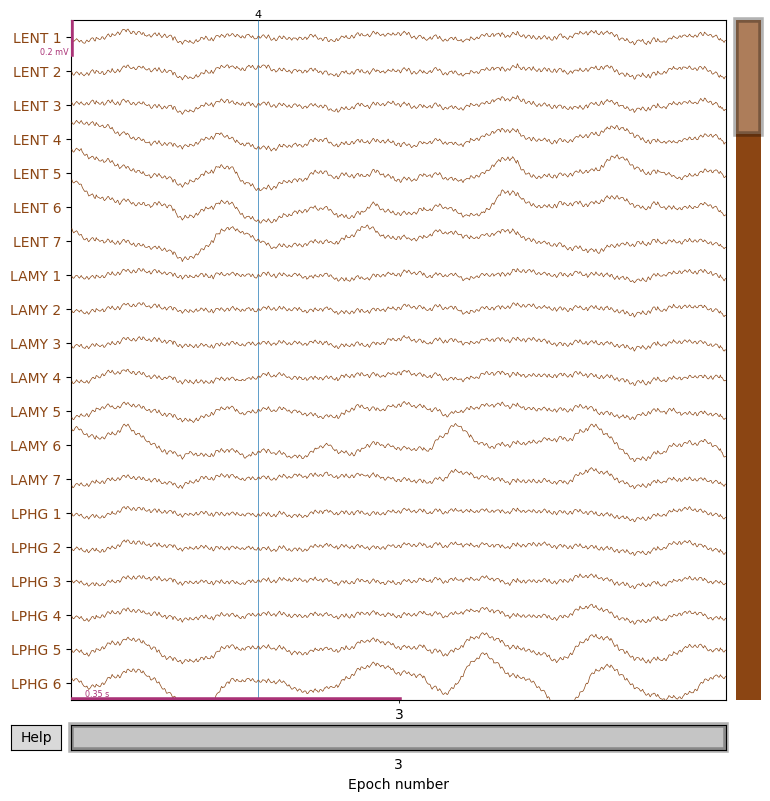

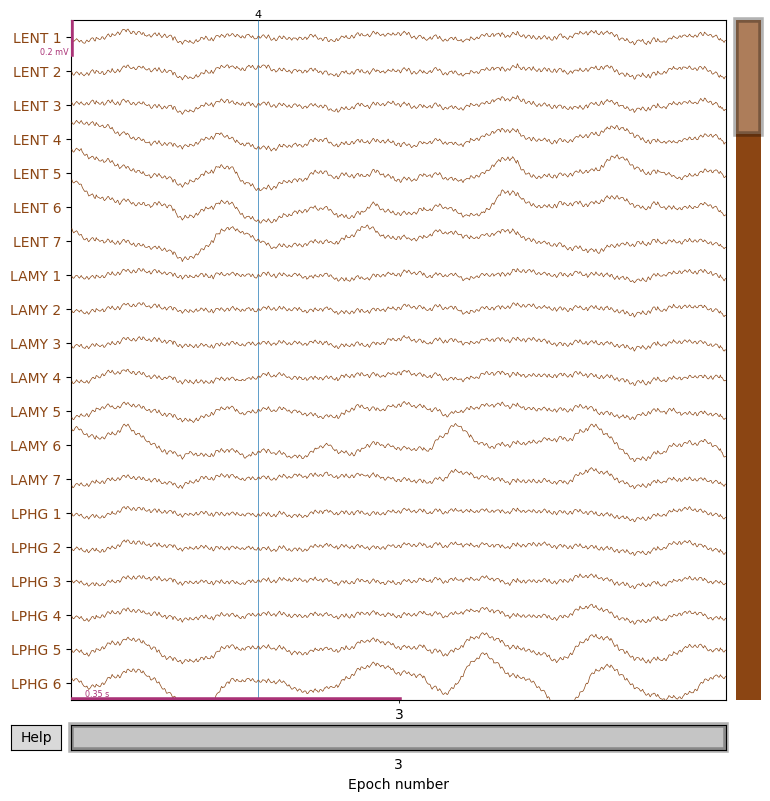

In [ ]:
epochs.plot(events=True)

In [ ]:
# get standard fsaverage volume (5mm grid) source space

fname_src = subjects_dir / "fsaverage" / "bem" / "fsaverage-vol-5-src.fif"
vol_src = mne.read_source_spaces(fname_src)

evoked = epochs.average()
stc = mne.stc_near_sensors(
    evoked,
    trans,
    "fsaverage",
    subjects_dir=subjects_dir,
    src=vol_src,
    surface=None,
    verbose="error",
)
stc = abs(stc)  # just look at magnitude
clim = dict(kind="value", lims=np.percentile(abs(evoked.data), [10, 50, 75]))

    Reading a source space...
    [done]
    1 source spaces read


Using notebook 3d backend.


2026-03-02 09:42:08.665 (  30.073s) [    7F4B2B2E04C0]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Exception in callback <_asyncio.TaskStepMethWrapper object at 0x7f498c06b490>()
handle: <Handle <_asyncio.TaskStepMethWrapper object at 0x7f498c06b490>()>
Traceback (most recent call last):
  File "/home/aboschun/.conda/envs/miplab/lib/python3.14/asyncio/events.py", line 94, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f4b0e28f8c0> is already entered
Exception in callback <_asyncio.TaskStepMethWrapper object at 0x7f498ac53d90>()
handle: <Handle <_asyncio.TaskStepMethWrapper object at 0x7f498ac53d90>()>
Traceback (most recent call last):
  File "/home/aboschun/.conda/envs/miplab/lib/python3.14/asyncio/events.py", line 94, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f4b0e28f8c0> is already entered
Exception in callback 

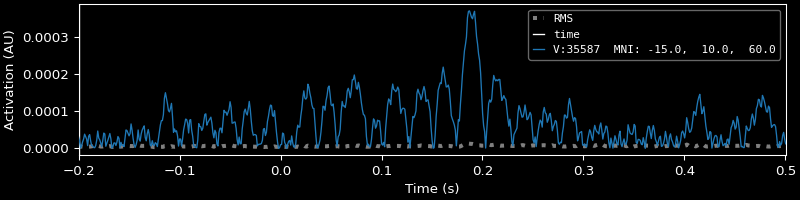

In [ ]:

brain = stc.plot_3d(
    src=vol_src,
    subjects_dir=subjects_dir,
    view_layout="horizontal",
    views=["axial", "coronal", "sagittal"],
    size=(800, 300),
    show_traces=0.4,
    clim=clim,
    add_data_kwargs=dict(colorbar_kwargs=dict(label_font_size=8)),
)

# You can save a movie like the one on our documentation website with:
# brain.save_movie(time_dilation=3, interpolation='linear', framerate=5,
#                  time_viewer=True, filename='./mne-test-seeg.m4')

Now let's do the same with our data :

In [4]:
#subjects_dir = sample_path / "subjects"
sample_path = "/media/RCPNAS/sEEG_MARS_Alison/"
subjects_dir = "/media/RCPNAS/sEEG_MARS_Alison/sub-01"

In [5]:
from pathlib import Path
import mne
import mne_bids
from mne_bids import BIDSPath, read_raw_bids
import pandas as pd

# Your BIDS root
bids_root = Path("/media/RCPNAS/sEEG_MARS_Alison")

# FreeSurfer subjects directory - this is the key path!
subjects_dir = bids_root / "sourcedata" / "reconstructions" / "PAT_3455" / "surf"

# Verify the PAT3455 subject exists
pat3455_path = bids_root / "sourcedata" / "reconstructions"
print(f"PAT3455 path exists: {pat3455_path.exists()}")
if pat3455_path.exists():
    print("Found FreeSurfer subject PAT3455 with directories:")
    print([d.name for d in pat3455_path.iterdir() if d.is_dir()])

# Now create mapping for all subjects
# Based on your folder structure, we need to map each BIDS subject to the correct patient
subject_to_fs = {
    "02": "PAT_3455",  #
}

# Process sub-01
subject = "02"
session = "retrieval"
task = "mars"
fs_subject = subject_to_fs[subject]

print(f"\nProcessing {subject} → FreeSurfer subject: {fs_subject}")
print(f"FreeSurfer directory: {subjects_dir / fs_subject}")

# Create BIDS path
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

# Read data
print(f"\nLoading data from: {bids_path.fpath}")
raw = read_raw_bids(bids_path, verbose=False)

# Load bad annotations
bad_annotation_path = bids_root / subject / f"ses-{session}" / "ieeg" / f"{subject}_ses-{session}_task-{task}_annot.csv"
if bad_annotation_path.exists():
    bad_annotations = mne.read_annotations(bad_annotation_path)
    bad_annotations.set_orig_time(None)
    raw.set_annotations(raw.annotations + bad_annotations)
    print(f"Added {len(bad_annotations)} bad annotations")

# Now visualize electrodes on brain
print(f"\nCreating brain visualization for {fs_subject}")

# Set MNE 3D backend for headless/remote
import os
#os.environ['PYVISTA_OFF_SCREEN'] = 'true'

matplotlib.use('Agg')  # Use non-interactive backend

# Use matplotlib backend (doesn't need display)
mne.viz.set_3d_backend('notebook')
#mne.viz.set_3d_backend('pyvistaqt')

# Create brain
brain = mne.viz.Brain(
    fs_subject,
    subjects_dir=str(pat3455_path),  # This points to the freesurfer folder containing HL1996
    cortex="low_contrast",
    alpha=0.25,
    background="white",
    figure=1,
)

# Add electrodes if montage exists
if raw.get_montage() is not None:
    try:
        trans = mne.channels.compute_native_head_t(raw.get_montage())
        brain.add_sensors(raw.info, trans=trans)
        print("Added electrodes to brain")
    except Exception as e:
        print(f"Could not add electrodes: {e}")
montage = raw.get_montage()
print(f"Montage exists: {montage is not None}")

if montage is None:
    print("\nNo montage found in raw data.")
    print("Looking for electrodes.tsv file...")
    
    # Look for electrodes.tsv
    electrodes_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_electrodes.tsv"
    print(f"Electrodes file exists: {electrodes_path.exists()}")
    
    if electrodes_path.exists():
        # Read electrodes.tsv
        electrodes_df = pd.read_csv(electrodes_path, sep='\t')
        print(f"\nElectrodes file contents:")
        print(f"Columns: {electrodes_df.columns.tolist()}")
        print(f"Number of electrodes: {len(electrodes_df)}")
        print("\nFirst few electrodes:")
        print(electrodes_df.head())
        
        # Check coordinate columns
        coord_cols = ['x', 'y', 'z']
        if all(col in electrodes_df.columns for col in coord_cols):
            print("\n✓ Found coordinate columns (x, y, z)")
            
            # Create montage
            montage = mne.channels.make_dig_montage(
                ch_pos=dict(zip(electrodes_df['name'], 
                               electrodes_df[coord_cols].values)),
                coord_frame='mri'  # or 'head' - check which one
            )
            raw.set_montage(montage)
            print(f"✓ Created and set montage with {len(electrodes_df)} electrodes")
        else:
            print(f"✗ Expected coordinate columns not found. Available columns: {electrodes_df.columns.tolist()}")
    else:
        print("✗ No electrodes.tsv file found in BIDS directory")
        
        # Look for alternative coordinate files
        coord_files = list(Path(bids_root / f"sub-{subject}").rglob("*coord*"))
        print(f"Alternative coordinate files found: {coord_files}")
#brain.add_head(alpha=0.25, color="tan")

# Save images
output_dir = Path.cwd() / "figures"
output_dir.mkdir(exist_ok=True)

# Save different views
views = [
    ("lateral_right", dict(azimuth=90, elevation=90, distance=400)),
    ("lateral_left", dict(azimuth=-90, elevation=90, distance=400)),
    ("top", dict(azimuth=0, elevation=90, distance=400)),
    ("front", dict(azimuth=0, elevation=0, distance=400)),
    ("back", dict(azimuth=180, elevation=0, distance=400)),
]

for view_name, view_kwargs in views:
    brain.show_view(**view_kwargs)
    output_file = output_dir / f"{subject}_electrodes_{view_name}.png"
    brain.save_image(str(output_file))
    print(f"Saved: {output_file}")

brain.close()
print(f"\nAll images saved to {output_dir}")

PAT3455 path exists: True
Found FreeSurfer subject PAT3455 with directories:
['PAT_3455', 'PatientHL1996', 'PAT_3390', 'PAT_2868']

Processing 02 → FreeSurfer subject: PAT_3455
FreeSurfer directory: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455/surf/PAT_3455

Loading data from: /media/RCPNAS/sEEG_MARS_Alison/sub-02/ses-retrieval/ieeg/sub-02_ses-retrieval_task-mars_ieeg.vhdr

Creating brain visualization for PAT_3455


/tmp/ipykernel_2351270/4227538899.py:48: RuntimeWarning: Did not find any electrodes.tsv associated with sub-02_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-02/**/ieeg/sub-02_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_2351270/4227538899.py:48: RuntimeWarning: Did not find any coordsystem.json associated with sub-02_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-02/**/ieeg/sub-02_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path, verbose=False)
2026-03-02 09:48:17.111 (  44.442s) [    7F4B409424C0]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Montage exists: False

No montage found in raw data.
Looking for electrodes.tsv file...
Electrodes file exists: False
✗ No electrodes.tsv file found in BIDS directory
Alternative coordinate files found: []
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_lateral_right.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_lateral_left.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_top.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_front.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_back.png

All images saved to /home/aboschun/MIPlab-Project/figures


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from mne_bids import BIDSPath, read_raw_bids

# Your paths
bids_root = Path("/media/RCPNAS/sEEG_MARS_Alison")

# For PAT_3455, figure out which BIDS subject this is
# Based on your earlier mapping, PAT_3455 might be sub-03 or sub-04
# Let's check participants.tsv if it exists
participants_file = bids_root / "participants.tsv"
if participants_file.exists():
    participants = pd.read_csv(participants_file, sep='\t')
    print("Participants mapping:")
    print(participants)

# For now, let's assume PAT_3455 is sub-03 (adjust based on your mapping)
subject = "02"  # Change this based on actual mapping
session = "retrieval"
task = "mars"

# Load raw data to get channel names in TRC order
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

raw = read_raw_bids(bids_path, verbose=False)
trc_channel_names = raw.ch_names
#trc_channel_names = ['HAD1', 'HAD2', 'HAG1', 'HAG2', 'HPD1', 'HPD2', 'HPG1', 'HPG2']  
print(f"TRC channel names (first 10): {trc_channel_names[:10]}")
print(f"Total channels: {len(trc_channel_names)}")

# Path to electrode reconstruction files
elec_recon_path = bids_root / "sourcedata" / "reconstructions" / "PAT_3455" / "elec_recon"

# Choose which coordinate type to use (you said these are aligned with TRC order)
# Options: INF, LEPTO, LEPTOVOX, PIAL, PIALVOX, POSTIMPLANT
coord_type = "PIALVOX"  # or whichever you prefer
coord_file = elec_recon_path / f"PAT_3455.{coord_type}"

print(f"\nLoading coordinates from: {coord_file}")
print(f"File exists: {coord_file.exists()}")

if coord_file.exists():
    # Read the coordinate file
    # These are typically text files with coordinates in mm
    coords = []
    with open(coord_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):  # Skip empty lines and comments
                try:
                    # Parse x y z coordinates
                    parts = line.split()
                    if len(parts) >= 3:
                        x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
                        coords.append([x, y, z])
                except:
                    continue
    
    coords = np.array(coords)
    print(f"Loaded {len(coords)} coordinates")
    
    # Also load electrode names if available
    names_file = elec_recon_path / "PAT_3455.electrodeNames"
    if names_file.exists():
        with open(names_file, 'r') as f:
            electrode_names = [line.strip() for line in f if line.strip() and not line.startswith('#')]
        print(f"Loaded {len(electrode_names)} electrode names")
    else:
        electrode_names = [f"ELEC{i+1:03d}" for i in range(len(coords))]
    
    # Check if number matches TRC channels
    print(f"\nCoordinate count: {len(coords)}")
    print(f"TRC channel count: {len(trc_channel_names)}")
    print(f"Electrode names count: {len(electrode_names)}")
    
    if len(coords) == len(trc_channel_names):
        print("✓ Coordinate count matches TRC channels - using as-is")
        montage_coords = coords
        montage_names = trc_channel_names
    else:
        print("⚠️  Count mismatch - need to map coordinates to TRC channels")
        
        # Create mapping dictionary
        coord_dict = dict(zip(electrode_names, coords))
        
        # Map to TRC order
        montage_coords = []
        montage_names = []
        
        for ch_name in trc_channel_names:
            # Try exact match
            #if ch_name not in ["HAD1", "HAD2", "HAG1", "HAG2", "HPD1", "HPD2", "HPG1", "HPG2"] :
            #    continue
            if ch_name in coord_dict:
                montage_coords.append(coord_dict[ch_name])
                montage_names.append(ch_name)
            else:
                # Try without spaces/special chars
                ch_clean = ch_name.replace(' ', '').replace('-', '').replace("'", "")
                found = False
                for coord_name in coord_dict.keys():
                    coord_clean = coord_name.replace(' ', '').replace('-', '').replace("'", "")
                    if ch_clean in coord_clean or coord_clean in ch_clean:
                        montage_coords.append(coord_dict[coord_name])
                        montage_names.append(ch_name)
                        print(f"  Matched {ch_name} to {coord_name}")
                        found = True
                        break
                
                if not found:
                    print(f"  Warning: No match for {ch_name}")
                    montage_coords.append([np.nan, np.nan, np.nan])
                    montage_names.append(ch_name)
        
        montage_coords = np.array(montage_coords)
    
    # Create montage
    montage = mne.channels.make_dig_montage(
        ch_pos=dict(zip(montage_names, montage_coords)),
        coord_frame='mri'  # These are in MRI coordinates
    )
    
    # Set montage to raw
    raw.set_montage(montage)
    print(f"\n✓ Created montage with {len(montage_names)} electrodes")
    
    # Verify first few electrodes
    print("\nFirst 5 electrode positions:")
    for i, ch_name in enumerate(montage_names[:5]):
        pos = montage.get_positions()['ch_pos'][ch_name]
        print(f"  {ch_name}: ({pos[0]:.1f}, {pos[1]:.1f}, {pos[2]:.1f})")
    
    # Save montage for future use
    montage_path = Path.cwd() / f"sub-{subject}_montage.fif"
    montage.save(montage_path, overwrite=True)
    print(f"Saved montage to {montage_path}")
    
    # Now you can get volume labels if FreeSurfer subject exists
    fs_subject = "PAT_3455"
    subjects_dir = bids_root / "sourcedata" / "reconstructions"
    
    aseg_path = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455/mri/aseg.mgz"

    if Path(aseg_path).exists():
        try:
            labels, colors = mne.get_montage_volume_labels(
                montage,
                fs_subject,
                subjects_dir=str(subjects_dir),
                aseg="aseg"
            )
            
            results_df = pd.DataFrame({
                'channel': montage_names,
                'label': labels,
                'color': colors
            })
            
            output_path = Path.cwd() / f"sub-{subject}_electrode_labels.csv"
            results_df.to_csv(output_path, index=False)
            print(f"Saved electrode labels to {output_path}")
            
        except Exception as e:
            print(f"Could not get volume labels: {e}")
    else:
        print(f"FreeSurfer aseg file not found at {aseg_path} - cannot get volume labels")

Participants mapping:
  participant_id  age  sex  hand  weight  height
0         sub-01  NaN  NaN   NaN     NaN     NaN
1         sub-02  NaN  NaN   NaN     NaN     NaN
2         sub-03  NaN  NaN   NaN     NaN     NaN
3         sub-04  NaN  NaN   NaN     NaN     NaN
4         sub-06  NaN  NaN   NaN     NaN     NaN
TRC channel names (first 10): ['AD1', 'AD2', 'AD3', 'AD4', 'AD5', 'AD6', 'AD7', 'AD8', 'HAD1', 'HAD2']
Total channels: 120

Loading coordinates from: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455/elec_recon/PAT_3455.PIALVOX
File exists: True
Loaded 116 coordinates
Loaded 118 electrode names

Coordinate count: 116
TRC channel count: 120
Electrode names count: 118
⚠️  Count mismatch - need to map coordinates to TRC channels
  Matched AD1 to AD1 D R
  Matched AD2 to AD2 D R
  Matched AD3 to AD3 D R
  Matched AD4 to AD4 D R
  Matched AD5 to AD5 D R
  Matched AD6 to AD6 D R
  Matched AD7 to AD7 D R
  Matched AD8 to AD8 D R
  Matched HAD1 to HAD1 D R
  Matched 

/tmp/ipykernel_2351270/1139237774.py:35: RuntimeWarning: Did not find any electrodes.tsv associated with sub-02_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-02/**/ieeg/sub-02_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_2351270/1139237774.py:35: RuntimeWarning: Did not find any coordsystem.json associated with sub-02_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-02/**/ieeg/sub-02_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_2351270/1139237774.py:134: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)
/tmp/ipykernel_2351270/1139237774.py:134: RuntimeWarning: Not setting positions of 4 ecg/stim channels found in montage:
['MKR1+', 'photodiode', 'MKR2+', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel

Saved montage to /home/aboschun/MIPlab-Project/sub-02_montage.fif
Could not get volume labels: index -102419 is out of bounds for axis 0 with size 256


In [7]:

montage.get_positions()

{'ch_pos': OrderedDict([('AD1', array([102.548236, 132.224746, 131.442678])),
              ('AD2', array([ 99.322355, 133.337119, 130.664017])),
              ('AD3', array([ 96.096473, 134.449492, 129.885356])),
              ('AD4', array([ 92.870591, 135.561865, 129.106694])),
              ('AD5', array([ 89.644709, 136.674238, 128.328033])),
              ('AD6', array([ 86.418828, 137.786611, 127.549372])),
              ('AD7', array([108., 130., 147.])),
              ('AD8', array([104.7109  , 130.290215, 145.839141])),
              ('HAD1', array([101.421799, 130.580429, 144.678282])),
              ('HAD2', array([ 98.132699, 130.870644, 143.517423])),
              ('HAD3', array([ 94.843598, 131.160859, 142.356564])),
              ('HAD4', array([ 91.554498, 131.451074, 141.195705])),
              ('HAD5', array([ 88.265397, 131.741288, 140.034846])),
              ('HAD6', array([ 84.976297, 132.031503, 138.873987])),
              ('HAD7', array([ 81.687196, 132.3217

In [11]:
aseg = "aparc+aseg"  # parcellation/anatomical segmentation atlas
path_atlas = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions"
montage = raw.get_montage()

from mne.channels import make_dig_montage

pos = montage.get_positions()

ch_pos_m = {
    ch: coord / 1000.0  # convert mm → meters
    for ch, coord in pos['ch_pos'].items()
}

montage_m = make_dig_montage(
    ch_pos=ch_pos_m,
    coord_frame="mri"
)

#montage.ch_names = [ch for ch in montage.ch_names if ch not in ['IPD14', 'IPD15']]
#montage.get_positions()['ch_pos'] = {ch: pos for ch, pos in montage.get_positions()['ch_pos'].items() if ch not in ['IPD14', 'IPD15']}

labels, colors = mne.get_montage_volume_labels(
    montage_m, "PAT_3455", subjects_dir=path_atlas, aseg=aseg
)
print(f"Labels: {labels}")
# separate by electrodes which have names like LAMY 1
electrodes = set(
    [
        "".join([lttr for lttr in ch_name if not lttr.isdigit() and lttr != " "])
        for ch_name in montage.ch_names
    ]
)
print(f"Electrodes in the dataset: {electrodes}")
print(epochs.ch_names)
#electrodes = ['HAD1', 'HAD2', 'HPD1', 'HPD2'] # choose two for this example

for elec in electrodes:
    picks = [ch_name for ch_name in montage.ch_names if elec in ch_name] #[elec] 
    print(picks)
    fig, ax = mne.viz.plot_channel_labels_circle(labels, colors, picks=picks)
    fig.text(0.3, 0.9, "Anatomical Labels", color="white")
    fig.savefig(f"figures/{subject}_{elec}_labels.png", dpi=300)

IndexError: index 261 is out of bounds for axis 2 with size 256

In [9]:
picks = [
    ii
    for ii, ch_name in enumerate(montage.ch_names)
    if any([elec in ch_name for elec in electrodes])
]
labels = (
    "ctx-rh-parahippocampal",
    "ctx-rh-fusiform",
    'Right-Inf-Lat-Vent', 
    'Right-Hippocampus'
)

fig = mne.viz.plot_alignment(
    mne.pick_info(epochs.info, picks),
    trans,
    "fsaverage",
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

brain = mne.viz.Brain(
    "PAT_3455",
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=subjects_dir,
    units="m",
    figure=fig,
)
brain.add_volume_labels(aseg="aparc+aseg", labels=labels)

brain.show_view(azimuth=120, elevation=90, distance=0.5, )
brain.save_image("figures/regions_mydata01.png")

brain.show_view(azimuth=60, elevation=90, distance=0.5)
brain.save_image("figures/regions_mydata02.png")

brain.show_view(azimuth=60, elevation=45, distance=0.5)
brain.save_image("figures/regions_mydata03.png")

brain.show_view(azimuth=0, elevation=45, distance=0.5)
brain.save_image("figures/regions_mydata04.png")

brain.show_view(azimuth=30, elevation=45, distance=0.5)
brain.save_image("figures/regions_mydata05.png")

NameError: name 'electrodes' is not defined